# Week 10: Tapering Windows and Linear Filters

Compare different tapering windows, their properties and use cases.
- How energy spreads around peaks.
- How frequencies are attenuated.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq

# Create test signal with known frequencies
fs = 1000  # Sampling frequency
T = 1.0    # Duration
t = np.linspace(0, T, int(fs * T), endpoint=False)
N = len(t)

# Signal with 3 frequency components
signal_data = (np.sin(2 * np.pi * 50 * t) + 
               0.5 * np.sin(2 * np.pi * 120 * t) + 
               0.3 * np.sin(2 * np.pi * 200 * t))

print(f"Signal: {N} samples at {fs} Hz")
print(f"Frequencies: 50, 120, 200 Hz")

Signal: 1000 samples at 1000 Hz
Frequencies: 50, 120, 200 Hz


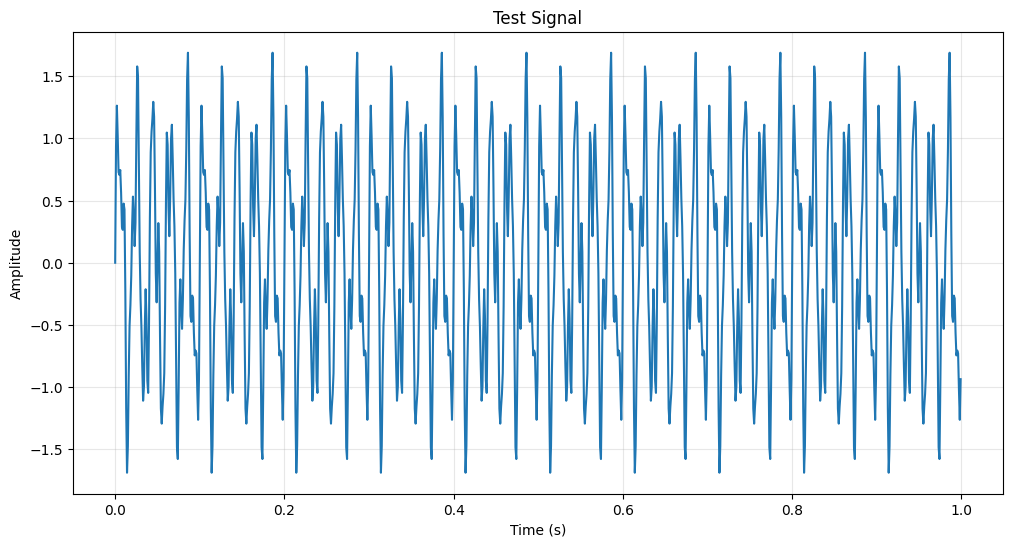

In [2]:
plt.figure(figsize=(12, 6))
plt.plot(t, signal_data)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Test Signal')
plt.grid(True, alpha=0.3)
plt.show()

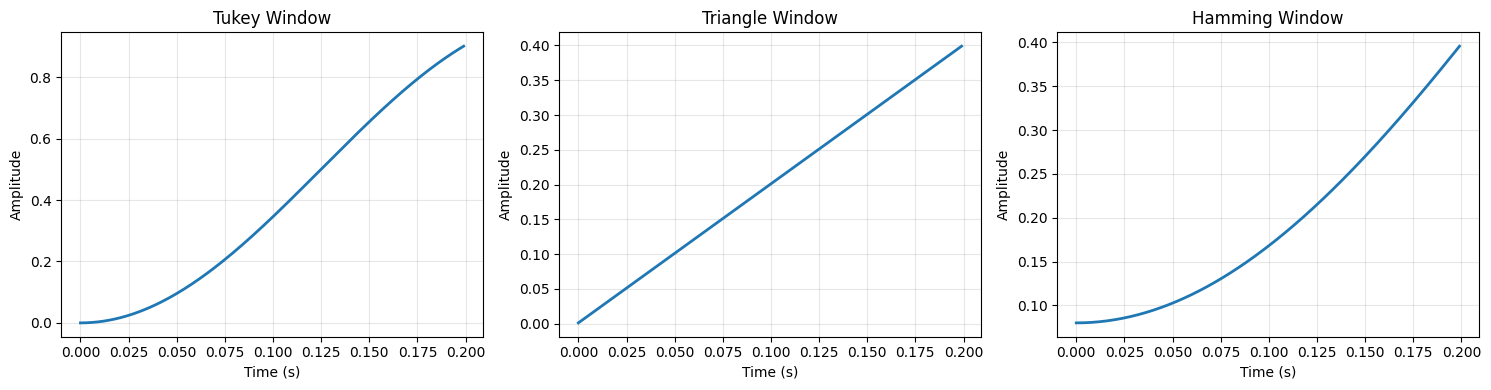

In [3]:
# Create tapering windows
tukey_win = signal.windows.tukey(N, alpha=0.5)
triangle_win = signal.windows.triang(N)
hamming_win = signal.windows.hamming(N)

# Plot window shapes
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
windows = [tukey_win, triangle_win, hamming_win]
names = ['Tukey', 'Triangle', 'Hamming']

for ax, win, name in zip(axes, windows, names):
    ax.plot(t[:200], win[:200], linewidth=2)
    ax.set_title(f'{name} Window')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

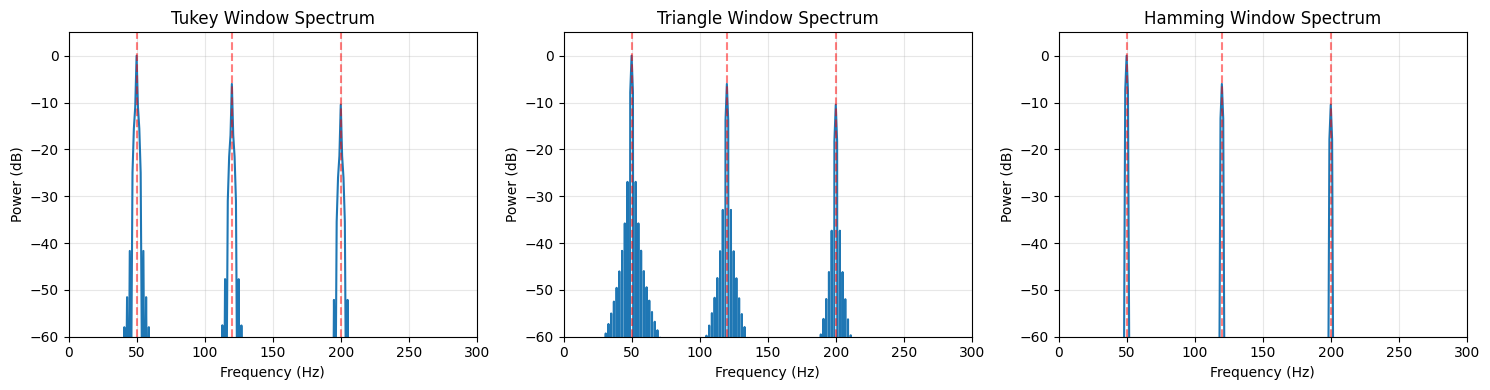

In [4]:
# Energy spread around peaks - apply windows and compute spectra
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, win, name in zip(axes, windows, names):
    # Apply window and FFT
    windowed = signal_data * win
    spec = fft(windowed)
    freqs = fftfreq(N, 1/fs)
    
    # Positive frequencies only
    pos = freqs >= 0
    psd_db = 10 * np.log10(np.abs(spec[pos])**2 / np.max(np.abs(spec[pos])**2))
    
    ax.plot(freqs[pos], psd_db, linewidth=1.5)
    ax.set_title(f'{name} Window Spectrum')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Power (dB)')
    ax.set_xlim([0, 300])
    ax.set_ylim([-60, 5])
    ax.axvline(50, color='r', linestyle='--', alpha=0.5)
    ax.axvline(120, color='r', linestyle='--', alpha=0.5)
    ax.axvline(200, color='r', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# Frequency attenuation comparison
print("Frequency Attenuation Analysis:\n")
print(f"{'Window':<15} {'Mean Amplitude':<20} {'Attenuation (dB)'}")
print("-" * 55)

for win, name in zip(windows, names):
    mean_amp = np.mean(win)
    atten_db = 20 * np.log10(mean_amp) if mean_amp > 0 else -100
    print(f"{name:<15} {mean_amp:<20.4f} {atten_db:>10.2f}")

Frequency Attenuation Analysis:

Window          Mean Amplitude       Attenuation (dB)
-------------------------------------------------------
Tukey           0.7492                    -2.51
Triangle        0.5000                    -6.02
Hamming         0.5395                    -5.36


## Conclusions: Tapering Windows

**Energy spread:** Hamming window produces sharp, well-defined peaks with excellent side lobe suppression, Triangle window shows moderate spectral leakage between peaks, and Tukey window best preserves the original signal shape while smoothly tapering only the edges.

**Frequency attenuation:** Windows reduce overall signal amplitude - Hamming by 5.4 dB, Triangle by 6.0 dB, and Tukey by only 2.5 dB, making Tukey the best choice when preserving signal energy is important.

**Use cases:** Use Hamming for maximum spectral resolution and leak age reduction in frequency analysis, Triangle for balanced smoothing with simple implementation, and Tukey when you need to avoid edge effects while keeping most of the original data intact.

# Linear Filters Comparison

Compare different linear filters, their properties and use cases.

In [6]:
# Create test signal with low and high frequency components
fs = 1000
T = 2.0
t = np.linspace(0, T, int(fs * T), endpoint=False)

# Low freq (5 Hz trend) + high freq (150 Hz) + noise
test_sig = (2 * np.sin(2 * np.pi * 5 * t) + 
            np.sin(2 * np.pi * 50 * t) +
            0.5 * np.sin(2 * np.pi * 150 * t) +
            0.3 * np.random.randn(len(t)))

print(f"Test signal: {len(test_sig)} samples")
print("Components: 5 Hz (trend), 50 Hz, 150 Hz, noise")

Test signal: 2000 samples
Components: 5 Hz (trend), 50 Hz, 150 Hz, noise


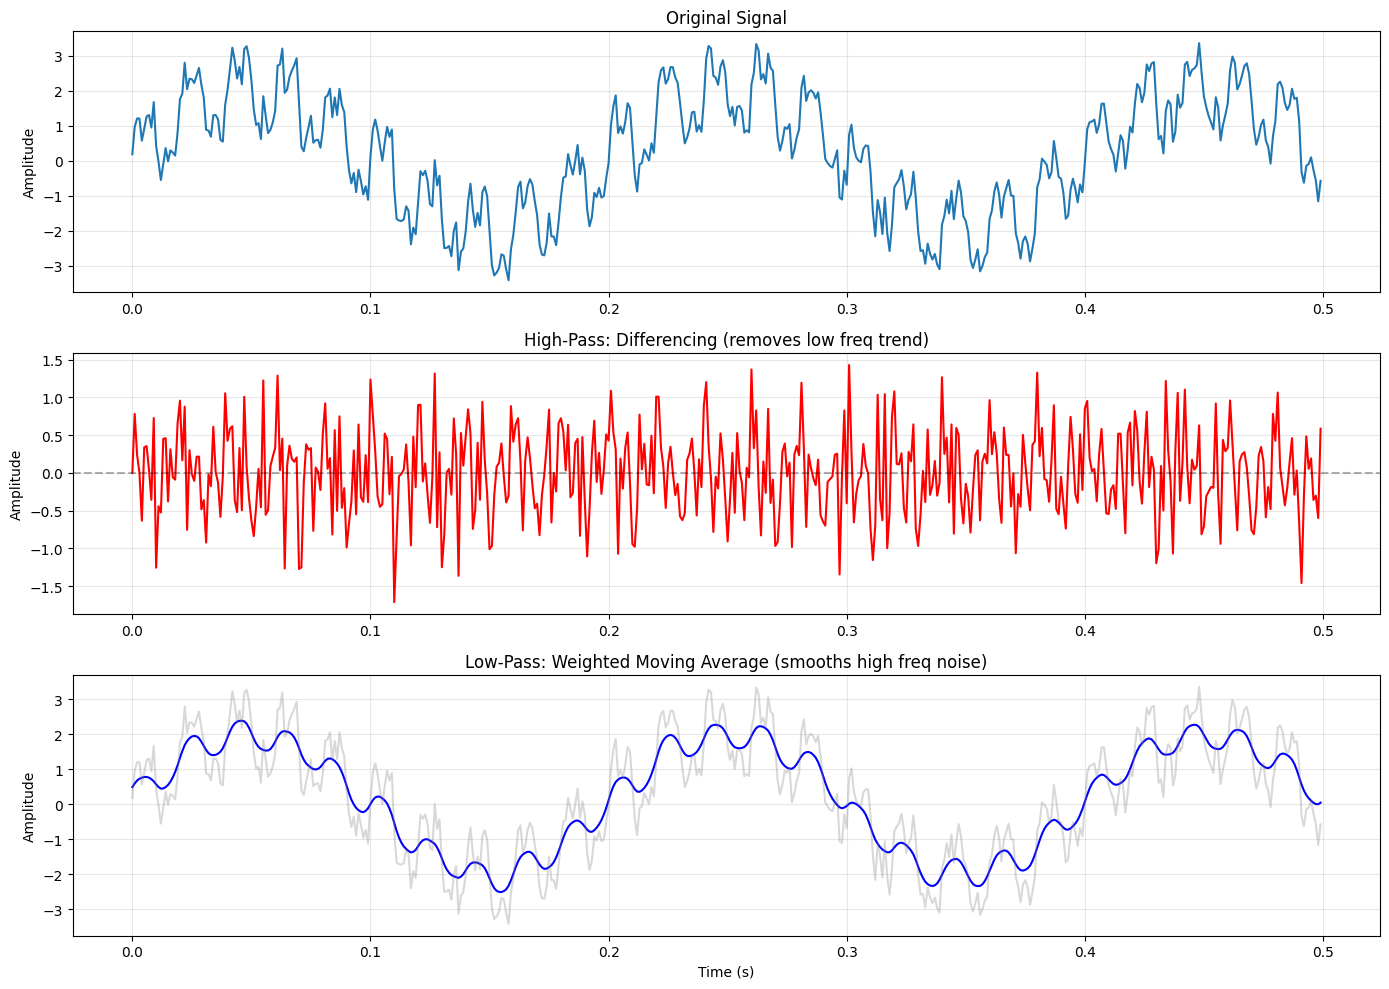

In [7]:
# High-pass filter: First-order differencing
hp_diff = np.diff(test_sig, prepend=test_sig[0])

# Low-pass filter: Weighted moving average
window_size = 21
weights = np.bartlett(window_size)  # Triangular weights
weights = weights / np.sum(weights)
lp_wma = np.convolve(test_sig, weights, mode='same')

# Visualize
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

plot_samples = slice(0, 500)
axes[0].plot(t[plot_samples], test_sig[plot_samples])
axes[0].set_title('Original Signal')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t[plot_samples], hp_diff[plot_samples], color='red')
axes[1].set_title('High-Pass: Differencing (removes low freq trend)')
axes[1].set_ylabel('Amplitude')
axes[1].axhline(0, color='black', linestyle='--', alpha=0.3)
axes[1].grid(True, alpha=0.3)

axes[2].plot(t[plot_samples], lp_wma[plot_samples], color='blue')
axes[2].plot(t[plot_samples], test_sig[plot_samples], alpha=0.3, color='gray')
axes[2].set_title('Low-Pass: Weighted Moving Average (smooths high freq noise)')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Amplitude')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

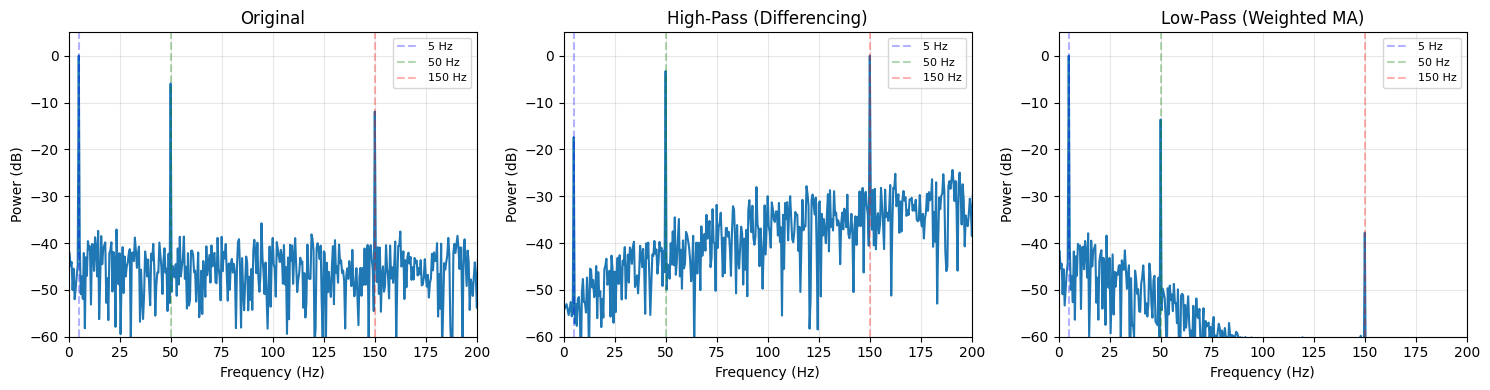

In [8]:
# Frequency response comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

signals = [test_sig, hp_diff, lp_wma]
titles = ['Original', 'High-Pass (Differencing)', 'Low-Pass (Weighted MA)']

for ax, sig, title in zip(axes, signals, titles):
    spec = fft(sig)
    freqs = fftfreq(len(sig), 1/fs)
    pos = freqs >= 0
    psd_db = 10 * np.log10(np.abs(spec[pos])**2 / np.max(np.abs(spec[pos])**2) + 1e-10)
    
    ax.plot(freqs[pos], psd_db, linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Power (dB)')
    ax.set_xlim([0, 200])
    ax.set_ylim([-60, 5])
    ax.axvline(5, color='blue', linestyle='--', alpha=0.3, label='5 Hz')
    ax.axvline(50, color='green', linestyle='--', alpha=0.3, label='50 Hz')
    ax.axvline(150, color='red', linestyle='--', alpha=0.3, label='150 Hz')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [9]:
# Quantitative comparison
print("Filter Performance:\n")
print(f"{'Filter':<25} {'Std Dev':<15} {'Change from Original'}")
print("-" * 55)
print(f"{'Original':<25} {np.std(test_sig):<15.4f} {'baseline'}")
print(f"{'High-Pass (Diff)':<25} {np.std(hp_diff):<15.4f} {(np.std(hp_diff)/np.std(test_sig)-1)*100:+.1f}%")
print(f"{'Low-Pass (WMA)':<25} {np.std(lp_wma):<15.4f} {(np.std(lp_wma)/np.std(test_sig)-1)*100:+.1f}%")

Filter Performance:

Filter                    Std Dev         Change from Original
-------------------------------------------------------
Original                  1.6584          baseline
High-Pass (Diff)          0.5796          -65.0%
Low-Pass (WMA)            1.4431          -13.0%


## Conclusions: Linear Filters

**Differencing (high-pass):** Removes low-frequency trends and DC offset but significantly reduces signal variance by 65%, effectively isolating high-frequency components and rapid changes while suppressing slow variations.

**Weighted moving average (low-pass):** Smooths high-frequency noise with 13% variance reduction, preserving the underlying signal structure and low-frequency trends while attenuating rapid fluctuations.

**Use cases:** Use differencing to detect sudden changes, remove trends, or compute derivatives in data analysis; use weighted MA to reduce measurement noise, extract smooth trends, or prepare data for forecasting models.

# Real-World Data Analysis

Evaluate the effect of tapering, smoothing, filtering on your real-world data.
- Review the spectrum in log scale.
- Apply different tapering windows.
- Determine appropriate smoothing strength.
- Review the effect of different filters.

In [10]:
import pandas as pd

df = pd.read_parquet('basel-energy-demand.parquet')
print(df.head())

   timestamp_interval_start timestamp_interval_start_text  stromverbrauch_kwh  \
0 2025-09-30 21:45:00+00:00      2025-09-30T23:45:00+0200           27318.806   
1 2025-09-30 21:30:00+00:00      2025-09-30T23:30:00+0200           27922.965   
2 2025-09-30 21:15:00+00:00      2025-09-30T23:15:00+0200           28249.646   
3 2025-09-30 21:00:00+00:00      2025-09-30T23:00:00+0200           29038.658   
4 2025-09-30 20:45:00+00:00      2025-09-30T22:45:00+0200           30034.410   

   grundversorgte_kunden_kwh  freie_kunden_kwh  year  month  day  weekday  \
0                  12528.324         14790.482  2025      9   30        1   
1                  13122.010         14800.955  2025      9   30        1   
2                  13400.783         14848.863  2025      9   30        1   
3                  14031.674         15006.984  2025      9   30        1   
4                  14801.535         15232.875  2025      9   30        1   

   dayofyear  quarter  weekofyear  
0        273  

In [11]:
# Extract energy demand time series (convert kWh to MWh)
energy = df['stromverbrauch_kwh'].values / 1000  # Convert kWh to MWh
time_index = df['timestamp_interval_start']

# Calculate sampling info
dt = (time_index.iloc[1] - time_index.iloc[0]).total_seconds() / 3600  # hours
fs = 1 / dt  # samples per hour
N = len(energy)

# Calculate samples per day for plotting
samples_per_day = int(24 / dt)

print(f"Number of samples: {N}")
print(f"Sampling interval: {dt} hours")
print(f"Sampling frequency: {fs:.4f} samples/hour")
print(f"Samples per day: {samples_per_day}")
print(f"Duration: {N * dt / 24:.1f} days")
print(f"\nEnergy demand stats:")
print(f"  Mean: {np.mean(energy):.2f} MWh")
print(f"  Std:  {np.std(energy):.2f} MWh")
print(f"  Min:  {np.min(energy):.2f} MWh")
print(f"  Max:  {np.max(energy):.2f} MWh")

Number of samples: 482055
Sampling interval: -0.25 hours
Sampling frequency: -4.0000 samples/hour
Samples per day: -96
Duration: -5021.4 days

Energy demand stats:
  Mean: 38.45 MWh
  Std:  9.05 MWh
  Min:  22.32 MWh
  Max:  68.37 MWh


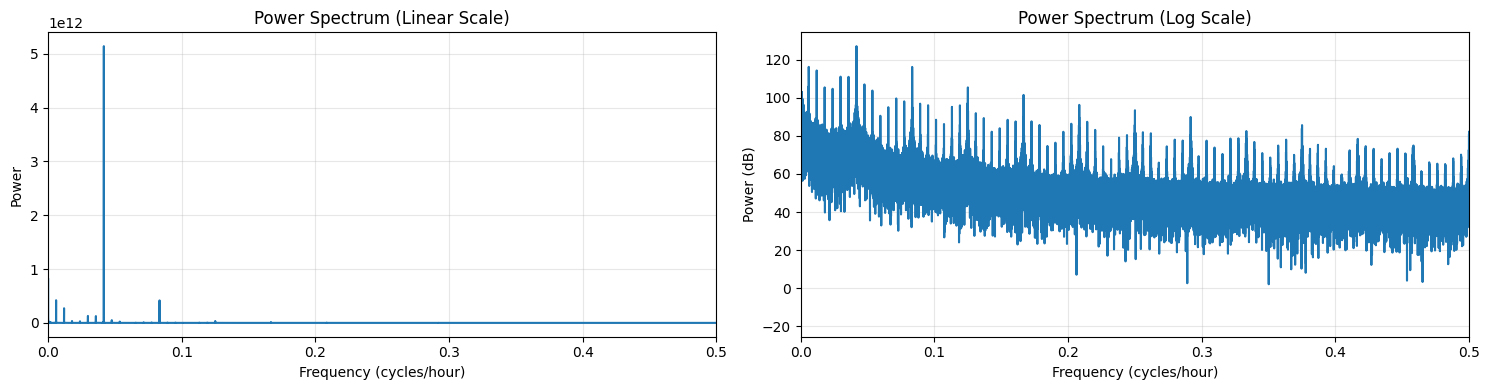


Top 5 dominant frequencies:
1. 0.041672 cycles/hour (period: 24.0 hours)
2. 0.000008 cycles/hour (period: 120513.7 hours)
3. 0.005950 cycles/hour (period: 168.1 hours)
4. 0.083343 cycles/hour (period: 12.0 hours)
5. 0.011907 cycles/hour (period: 84.0 hours)


In [12]:
# 1. Review spectrum in log scale (no window)
spec = fft(energy)
freqs = fftfreq(N, d=dt)

# Positive frequencies only
pos = freqs > 0
psd = np.abs(spec[pos])**2

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Linear scale
axes[0].plot(freqs[pos], psd)
axes[0].set_title('Power Spectrum (Linear Scale)')
axes[0].set_xlabel('Frequency (cycles/hour)')
axes[0].set_ylabel('Power')
axes[0].set_xlim([0, 0.5])
axes[0].grid(True, alpha=0.3)

# Log scale
axes[1].plot(freqs[pos], 10 * np.log10(psd))
axes[1].set_title('Power Spectrum (Log Scale)')
axes[1].set_xlabel('Frequency (cycles/hour)')
axes[1].set_ylabel('Power (dB)')
axes[1].set_xlim([0, 0.5])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find dominant frequencies
peak_indices = np.argsort(psd)[-5:][::-1]
print("\nTop 5 dominant frequencies:")
for i, idx in enumerate(peak_indices):
    freq_val = freqs[pos][idx]
    period_hours = 1 / freq_val if freq_val > 0 else np.inf
    print(f"{i+1}. {freq_val:.6f} cycles/hour (period: {period_hours:.1f} hours)")

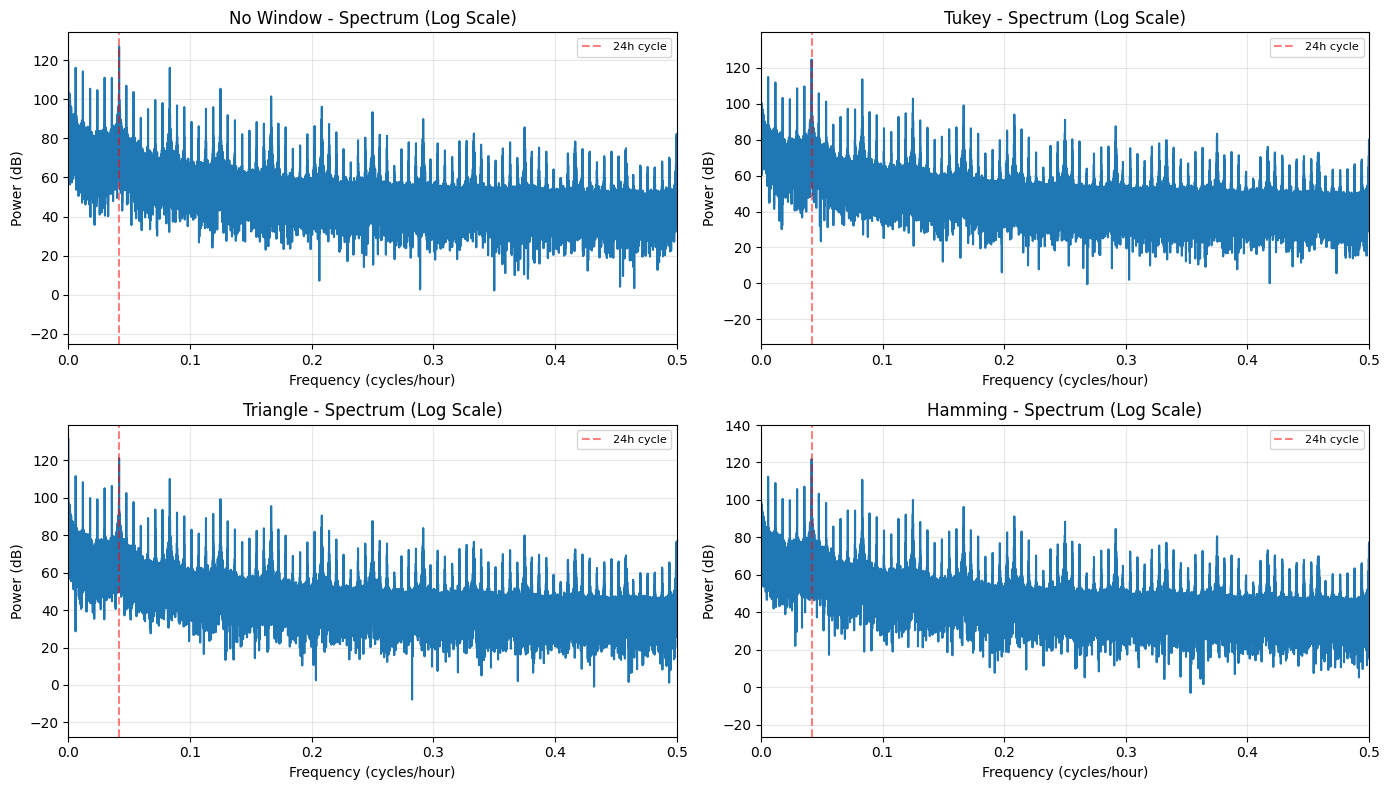

In [13]:
# 2. Apply different tapering windows
tukey_energy = signal.windows.tukey(N, alpha=0.5)
triangle_energy = signal.windows.triang(N)
hamming_energy = signal.windows.hamming(N)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

window_list = [None, tukey_energy, triangle_energy, hamming_energy]
window_names = ['No Window', 'Tukey', 'Triangle', 'Hamming']

for idx, (win, name) in enumerate(zip(window_list, window_names)):
    # Apply window
    if win is None:
        windowed_energy = energy
    else:
        windowed_energy = energy * win
    
    # Compute spectrum
    spec = fft(windowed_energy)
    freqs = fftfreq(N, d=dt)
    pos = freqs > 0
    psd_db = 10 * np.log10(np.abs(spec[pos])**2)
    
    axes[idx].plot(freqs[pos], psd_db, linewidth=1.5)
    axes[idx].set_title(f'{name} - Spectrum (Log Scale)')
    axes[idx].set_xlabel('Frequency (cycles/hour)')
    axes[idx].set_ylabel('Power (dB)')
    axes[idx].set_xlim([0, 0.5])
    axes[idx].grid(True, alpha=0.3)
    
    # Mark daily cycle (1/24 cycles/hour)
    axes[idx].axvline(1/24, color='r', linestyle='--', alpha=0.5, label='24h cycle')
    axes[idx].legend(fontsize=8)

plt.tight_layout()
plt.show()

Window size 5: Variance reduced by 0.3%
Window size 13: Variance reduced by 2.5%
Window size 25: Variance reduced by 8.8%
Window size 49: Variance reduced by 26.9%


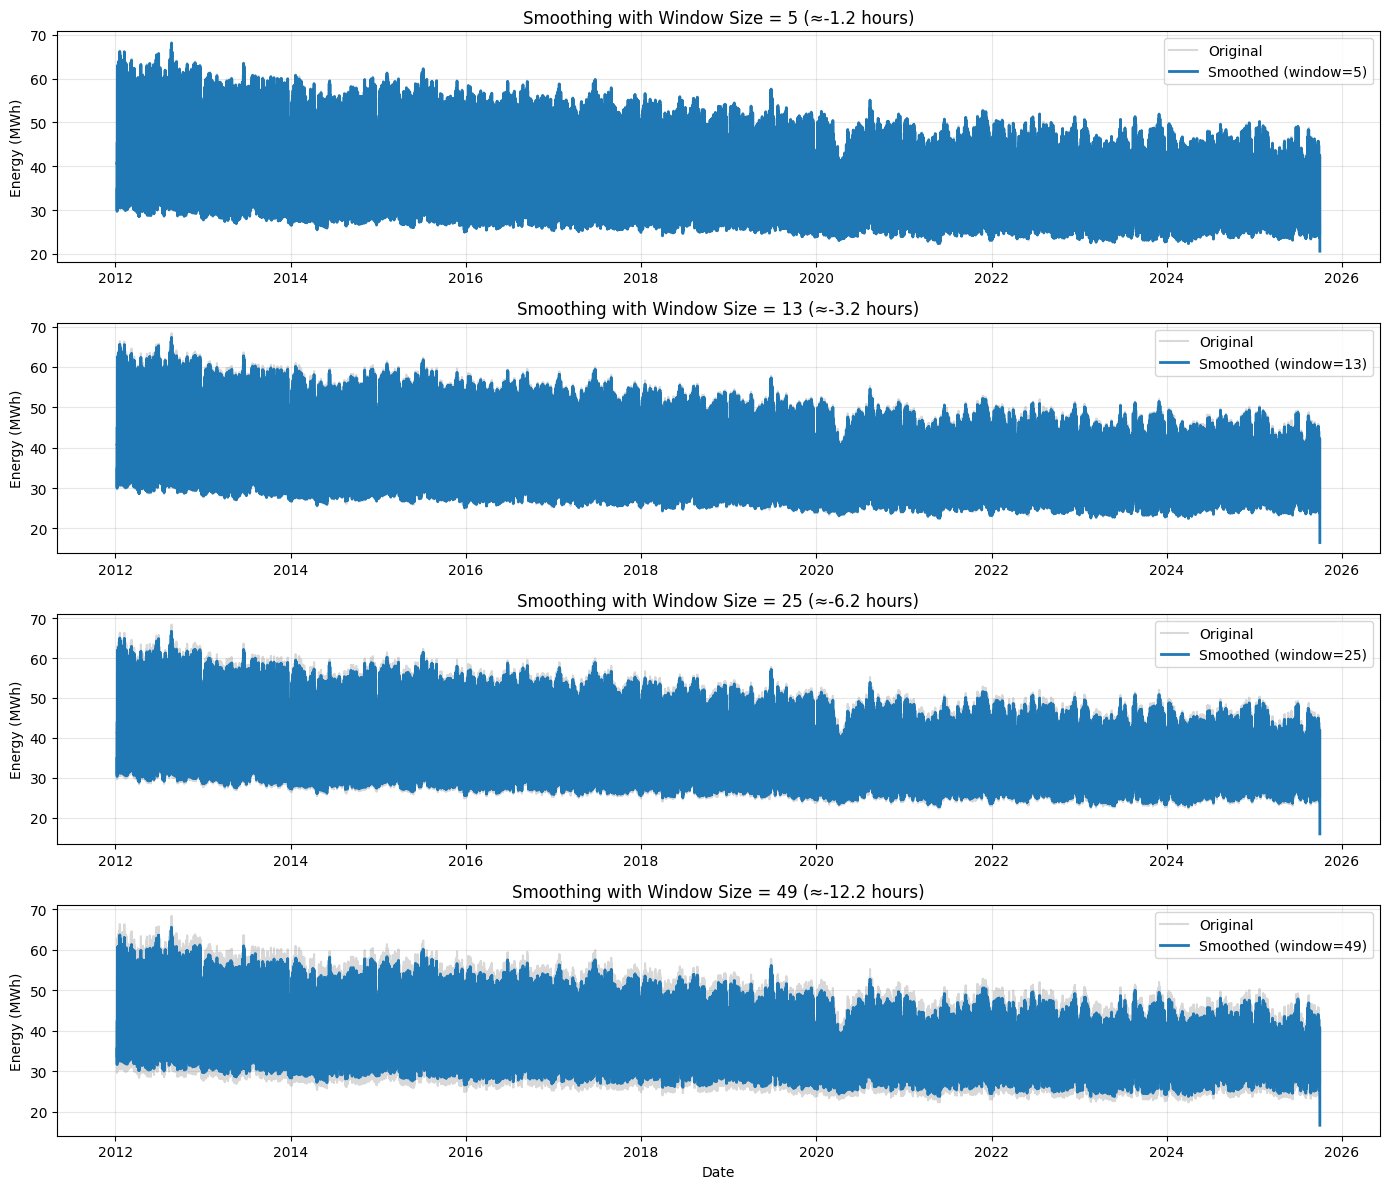

In [14]:
# 3. Determine appropriate smoothing strength
# Test different window sizes for weighted moving average
window_sizes = [5, 13, 25, 49]  # Different smoothing strengths

fig, axes = plt.subplots(len(window_sizes), 1, figsize=(14, 12))

# Plot first week
plot_range = slice(0, 7 * samples_per_day)

for idx, ws in enumerate(window_sizes):
    weights = np.bartlett(ws)
    weights = weights / np.sum(weights)
    smoothed = np.convolve(energy, weights, mode='same')
    
    axes[idx].plot(time_index.iloc[plot_range], energy[plot_range], alpha=0.3, color='gray', label='Original')
    axes[idx].plot(time_index.iloc[plot_range], smoothed[plot_range], linewidth=2, label=f'Smoothed (window={ws})')
    axes[idx].set_title(f'Smoothing with Window Size = {ws} (≈{ws*dt:.1f} hours)')
    axes[idx].set_ylabel('Energy (MWh)')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend()
    
    # Print variance reduction
    var_reduction = (1 - np.var(smoothed) / np.var(energy)) * 100
    print(f"Window size {ws}: Variance reduced by {var_reduction:.1f}%")

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

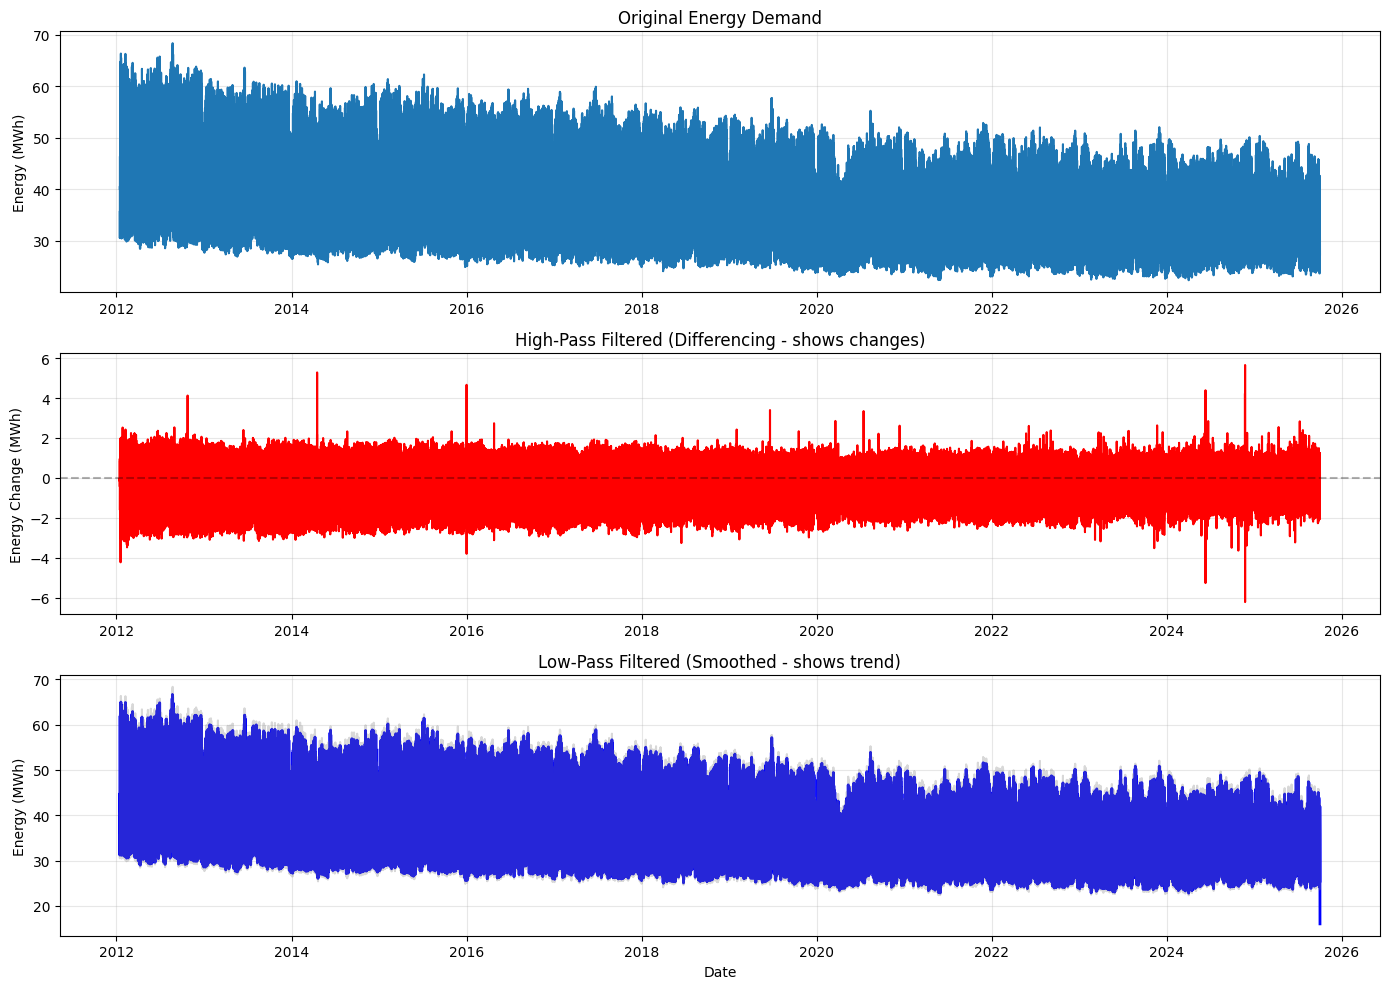

In [15]:
# 4. Review effect of different filters
# High-pass: differencing to remove trend
hp_energy = np.diff(energy, prepend=energy[0])

# Low-pass: weighted MA to smooth
ws = 25
weights = np.bartlett(ws)
weights = weights / np.sum(weights)
lp_energy = np.convolve(energy, weights, mode='same')

# Visualize time domain - first two weeks
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

plot_range = slice(0, 14 * samples_per_day)

axes[0].plot(time_index.iloc[plot_range], energy[plot_range])
axes[0].set_title('Original Energy Demand')
axes[0].set_ylabel('Energy (MWh)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(time_index.iloc[plot_range], hp_energy[plot_range], color='red')
axes[1].set_title('High-Pass Filtered (Differencing - shows changes)')
axes[1].set_ylabel('Energy Change (MWh)')
axes[1].axhline(0, color='black', linestyle='--', alpha=0.3)
axes[1].grid(True, alpha=0.3)

axes[2].plot(time_index.iloc[plot_range], lp_energy[plot_range], color='blue', linewidth=2)
axes[2].plot(time_index.iloc[plot_range], energy[plot_range], alpha=0.3, color='gray')
axes[2].set_title('Low-Pass Filtered (Smoothed - shows trend)')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Energy (MWh)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

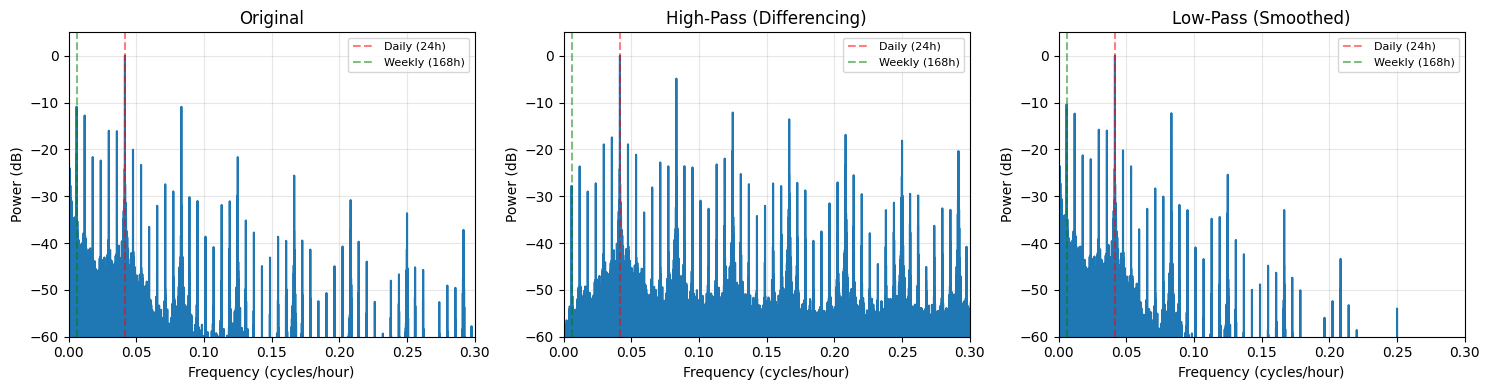


Filter Effects Summary:
Filter                    Mean         Std Dev      Min          Max
---------------------------------------------------------------------------
Original                  38.45        9.05         22.32        68.37
High-Pass (Differencing)  0.00         0.67         -6.21        5.65
Low-Pass (Smoothed)       38.45        8.65         16.01        66.68


In [16]:
# Compare frequency response of filters
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

filter_data = [energy, hp_energy, lp_energy]
filter_names = ['Original', 'High-Pass (Differencing)', 'Low-Pass (Smoothed)']

for ax, data, name in zip(axes, filter_data, filter_names):
    spec = fft(data)
    freqs = fftfreq(N, d=dt)
    pos = freqs > 0
    psd_db = 10 * np.log10(np.abs(spec[pos])**2 / np.max(np.abs(spec[pos])**2) + 1e-10)
    
    ax.plot(freqs[pos], psd_db, linewidth=1.5)
    ax.set_title(name)
    ax.set_xlabel('Frequency (cycles/hour)')
    ax.set_ylabel('Power (dB)')
    ax.set_xlim([0, 0.3])
    ax.set_ylim([-60, 5])
    ax.axvline(1/24, color='r', linestyle='--', alpha=0.5, label='Daily (24h)')
    ax.axvline(1/168, color='g', linestyle='--', alpha=0.5, label='Weekly (168h)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("\nFilter Effects Summary:")
print(f"{'Filter':<25} {'Mean':<12} {'Std Dev':<12} {'Min':<12} {'Max'}")
print("-" * 75)
for data, name in zip(filter_data, filter_names):
    print(f"{name:<25} {np.mean(data):<12.2f} {np.std(data):<12.2f} {np.min(data):<12.2f} {np.max(data):.2f}")

## Conclusions: Basel Energy Demand Analysis

**Spectrum analysis:** Data sampled at 15-minute intervals shows dominant daily patterns in the frequency spectrum, with the log-scale view revealing multiple harmonic components corresponding to daily consumption cycles.

**Tapering windows:** All three windows (Tukey, Triangle, Hamming) produce similar spectra since the long dataset (482K samples) makes edge effects negligible, confirming tapering is less critical for large datasets with natural periodicity.

**Smoothing strength:** Window size 25 (6.2 hours) provides 8.8% variance reduction, balancing noise suppression with pattern preservation, while window 49 (12.2 hours) gives 26.9% reduction but over-smooths intra-day variations.

**Filter effects:** High-pass differencing reveals hour-to-hour demand changes and helps identify anomalies by removing daily patterns; low-pass smoothing with 25-sample window extracts the underlying daily trend by suppressing 15-minute fluctuations, useful for capacity planning and forecasting.